In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pathlib import Path
from functools import reduce

import os
import pickle

import torch

tqdm.pandas()

simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

from pandarallel import pandarallel
pandarallel.initialize()

INFO: Pandarallel will run on 64 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
core_mimiciv_path = "/home/DAHS1/gangmin/my_research/data/mimic-iv/"
store_dir = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/"

key_id_icu = pd.read_feather(store_dir + 'key_id_static.ftr')

df_ditems = pd.read_parquet(core_mimiciv_path + "/icu/parquet/d_items.parquet")
df_dlabitems = pd.read_parquet(core_mimiciv_path + "/hosp/parquet/d_labitems.parquet")

# Outtime 결측값 제외
key_id_icu = key_id_icu.dropna(subset=['outtime']).reset_index(drop=True)

In [3]:
key_id_icu

,subject_id,hadm_id,stay_id,admittime,dischtime,edregtime,edouttime,intime,outtime,los,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,first_careunit,last_careunit
0,10000032,29079034,39553978,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
1,10000690,25860671,37081114,2150-11-02 18:02:00,2150-11-12 13:45:00,2150-11-02 11:41:00,2150-11-02 19:37:00,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
2,10000980,26913865,39765666,2189-06-27 07:38:00,2189-07-03 03:00:00,2189-06-27 06:25:00,2189-06-27 08:42:00,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
3,10001217,24597018,37067082,2157-11-18 22:56:00,2157-11-25 18:00:00,2157-11-18 17:38:00,2157-11-19 01:24:00,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)
4,10001217,27703517,34592300,2157-12-18 16:58:00,2157-12-24 14:55:00,None,None,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84201,19999442,26785317,32336619,2148-11-19 10:00:00,2148-12-04 16:25:00,None,None,2148-11-19 14:23:43,2148-11-26 13:12:15,6.950370,ELECTIVE,PHYSICIAN REFERRAL,REHAB,Medicaid,English,DIVORCED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)
84202,19999625,25304202,31070865,2139-10-10 18:06:00,2139-10-16 03:30:00,2139-10-10 16:44:00,2139-10-10 19:18:00,2139-10-10 19:18:00,2139-10-11 18:21:28,0.960741,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,Modern Greek (1453-),MARRIED,WHITE,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU)
84203,19999828,25744818,36075953,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,2149-01-08 18:12:00,2149-01-10 13:11:02,1.790995,EW EMER.,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
84204,19999840,21033226,38978960,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-10 11:09:00,2164-09-10 14:46:00,2164-09-12 09:26:28,2164-09-17 16:35:15,5.297766,EW EMER.,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)


In [4]:
# sequential df 불러오기
sequential_df_fluid = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_sequential_df_fluid.ftr")
sequential_df_bp = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_sequential_df_bp.ftr")
lab_imputed_chart = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_lab_imputed_chart.ftr")
sequential_df_output = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/full_sequential_df_output.ftr")

# 1. Static Processing

In [ ]:
# static df 불러오기
admissions = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/admissions.ftr')
patients = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/patients.ftr')
transfers = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/transfers.ftr')
icustays = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/icu/icustays.ftr")

In [15]:
# concatenating all information in patients, admissions, and icustays
static_info = patients.set_index('subject_id').join(admissions.set_index('subject_id'), how='left').reset_index()
static_info = static_info.set_index(['subject_id', 'hadm_id']).join(icustays.set_index(['subject_id', 'hadm_id']), how='left').reset_index()

In [16]:
static_info

,subject_id,hadm_id,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,22595853.0,F,52,2180,2014 - 2016,2180-09-09,2180-05-06 22:23:00,2180-05-07 17:15:00,None,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0.0,NaN,NaN,NaN,NaT,NaT,NaN
1,10000032,22841357.0,F,52,2180,2014 - 2016,2180-09-09,2180-06-26 18:27:00,2180-06-27 18:49:00,None,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0.0,NaN,NaN,NaN,NaT,NaT,NaN
2,10000032,25742920.0,F,52,2180,2014 - 2016,2180-09-09,2180-08-05 23:44:00,2180-08-07 17:50:00,None,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0.0,NaN,NaN,NaN,NaT,NaT,NaN
3,10000032,29079034.0,F,52,2180,2014 - 2016,2180-09-09,2180-07-23 12:35:00,2180-07-25 17:55:00,None,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0.0,39553978.0,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
4,10000048,NaN,F,23,2126,2008 - 2010,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696414,19999829,NaN,F,28,2186,2008 - 2010,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
696415,19999840,21033226.0,M,58,2164,2008 - 2010,2164-09-17,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00,EW EMER.,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,WHITE,2164-09-10 11:09:00,2164-09-10 14:46:00,1.0,38978960.0,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2164-09-12 09:26:28,2164-09-17 16:35:15,5.297766
696416,19999840,26071774.0,M,58,2164,2008 - 2010,2164-09-17,2164-07-25 00:27:00,2164-07-28 12:15:00,None,EW EMER.,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,WHITE,2164-07-24 21:16:00,2164-07-25 01:20:00,0.0,NaN,NaN,NaN,NaT,NaT,NaN
696417,19999914,NaN,F,49,2158,2017 - 2019,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


In [17]:
'''
subject에 대해 동일한 정보의 모음은 아래와 같다.
'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'language', 'race', 'dod', 'deathtime'

admission에 대해 동일한 정보의 모음은 아래와 같다.(위의 정보를 포함한다.)
'admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'edregtime', 'edouttime', 'hospital_expire_flag', 'admit_provider_id'

이를 검사해보자.
'''
identical_for_sub = ['gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'language', 'race', 'dod', 'deathtime']
identical_for_adm = identical_for_sub+['admittime', 'dischtime', 'admission_type', 'admission_location', 'discharge_location', 'insurance', 'marital_status', 'edregtime', 'edouttime', 'hospital_expire_flag', 'admit_provider_id']

def identical_test(x, identical):
    unique_rows = x[identical].drop_duplicates().reset_index(drop=True)
    
    if unique_rows.shape[0] == 1:
        return None
    else:
        tmp = []
        for idx in range(unique_rows.shape[0]-1):
           tmp += np.array(identical)[(unique_rows.iloc[idx]!=unique_rows.iloc[idx+1])&(~pd.isna(unique_rows).all())].tolist()
        tmp = list(set(tmp))
        unique_rows['unique'] = np.nan
        unique_rows['unique'] = unique_rows['unique'].astype(object)
        for idx in range(unique_rows.shape[0]):
            unique_rows.at[idx, 'unique'] = ', '.join(tmp)

        return unique_rows
    
tmp = static_info.groupby('subject_id').progress_apply(partial(identical_test, identical=identical_for_sub), include_groups=True)
try: print(set(', '.join(tmp['unique'].unique().tolist()).split(', ')))
except: pass

tmp = static_info.groupby('hadm_id').progress_apply(partial(identical_test, identical=identical_for_adm), include_groups=True)
try: print(set(', '.join(tmp['unique'].unique().tolist()).split(', ')))
except: pass

  0%|          | 0/364627 [00:00<?, ?it/s]

{'race', 'deathtime'}


/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


  0%|          | 0/546028 [00:00<?, ?it/s]

/home/DAHS1/.local/lib/python3.10/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)


- race: 첫 입원 때는 WHITE로 입력했는데, 다음 입원 때는 WHITE - BRAZILIAN이나 UNKNOWN으로 입력된 경우
- deathtime: 어떤 행에는 사망 시간이 기록되어 있는데, 이전 입원 기록 행에는 NaN으로 되어 있어서 두 행의 값이 서로 다르다고 판단한 경우

In [18]:
def id_num_check(static_info):
    print(f'subject_id: {len(static_info.subject_id.unique())}')
    print(f'hadm_id: {len(static_info.hadm_id.unique())}')
    print(f'stay_id: {len(static_info.stay_id.unique())}')

id_num_check(static_info)

subject_id: 364627
hadm_id: 546029
stay_id: 94459


In [19]:
# subjects without admission
tmp = static_info.groupby('subject_id')['hadm_id'].count().apply(lambda x: x==0)
static_info = static_info.loc[static_info.subject_id.isin(tmp[~tmp].index)].reset_index(drop=True)

# 이런 경우는 제거해도 될듯함
id_num_check(static_info)

subject_id: 223452
hadm_id: 546028
stay_id: 94459


In [20]:
# # admissions without stays
# tmp = static_info.groupby('hadm_id')['stay_id'].count().apply(lambda x: x==0)
# tmp.sum()
# # 이런 경우는 일단 남기고 이후에 상황을 보기로 함

In [21]:
# The normal order of these 4 timestamps is: admittime, intime, outtime, and dischtime.
transfers = transfers.loc[transfers['subject_id'].isin(static_info['subject_id'].unique())].reset_index(drop=True)
transfers['intime'] = pd.to_datetime(transfers['intime'])
transfers['outtime'] = pd.to_datetime(transfers['outtime'])
transfers = transfers.sort_values(['subject_id', 'intime'])
np.setdiff1d(transfers.hadm_id, static_info.hadm_id)

array([nan])

In [22]:
transfers

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
0,10000032,22595853.0,33258284,ED,Emergency Department,2180-05-06 19:17:00,2180-05-06 23:30:00
1,10000032,22595853.0,35223874,admit,Transplant,2180-05-06 23:30:00,2180-05-07 17:21:27
2,10000032,22595853.0,36904543,discharge,UNKNOWN,2180-05-07 17:21:27,NaT
5,10000032,22841357.0,38112554,ED,Emergency Department,2180-06-26 15:54:00,2180-06-26 21:31:00
4,10000032,22841357.0,34703856,admit,Transplant,2180-06-26 21:31:00,2180-06-27 18:49:12
...,...,...,...,...,...,...,...
2220211,19999840,21033226.0,31734955,discharge,UNKNOWN,2164-09-17 16:35:15,NaT
2220220,19999987,23865745.0,34731548,ED,Emergency Department,2145-11-02 19:28:00,2145-11-02 22:59:00
2220221,19999987,23865745.0,36195440,admit,Trauma SICU (TSICU),2145-11-02 22:59:00,2145-11-04 21:29:30
2220219,19999987,23865745.0,30249304,transfer,Neurology,2145-11-04 21:29:30,2145-11-11 13:00:47


In [23]:
# 첫 event가 transfer나 discharge인 case 확인 -> 잘못된 케이스
tmp = transfers.groupby('hadm_id')['eventtype'].first().reset_index()
tmp['eventtype'].value_counts()

eventtype
ED           374251
admit        171766
transfer          5
discharge         2
Name: count, dtype: int64

In [24]:
# 마지막 case 확인
tmp = transfers.groupby('hadm_id')['eventtype'].last().reset_index()
tmp['eventtype'].value_counts()

eventtype
discharge    546024
Name: count, dtype: int64

In [25]:
# if the first transfer event is "transfer", check those really transferred from other facilities.
tmp = transfers.groupby('hadm_id')['eventtype'].first().reset_index()
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])]['admission_location']
# it did actually

110607    TRANSFER FROM HOSPITAL
116170        PHYSICIAN REFERRAL
127703    TRANSFER FROM HOSPITAL
229343    TRANSFER FROM HOSPITAL
364709     WALK-IN/SELF REFERRAL
Name: admission_location, dtype: object

In [26]:
# dischtime과 비교
transfers[transfers['hadm_id'].isin(tmp[tmp['eventtype'].isin(['discharge'])]['hadm_id'])]

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
736293,13328242,28419467.0,30646598,discharge,UNKNOWN,2180-01-19 15:29:40,NaT
2154966,19703083,21086286.0,38829034,discharge,UNKNOWN,2122-01-02 18:25:07,NaT


In [27]:
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['discharge'])]['hadm_id'])][['hadm_id', 'admittime', 'dischtime']]
# dischtime을 transfer의 정보(intime)로 대체 가능할듯함

,hadm_id,admittime,dischtime
184451,28419467.0,2180-01-10 10:25:00,2180-01-19 15:29:00
538945,21086286.0,2121-12-03 09:30:00,2122-01-02 17:52:00


In [28]:
# admittime과 비교
transfers[transfers['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])].sort_values(['hadm_id', 'intime'])#.groupby('hadm_id').first().sort_index()

,subject_id,hadm_id,transfer_id,eventtype,careunit,intime,outtime
916604,14149834,23318596.0,37143734,transfer,Medical Intensive Care Unit (MICU),2189-03-16 21:25:25,2189-03-30 18:23:37
916605,14149834,23318596.0,37776032,discharge,UNKNOWN,2189-03-30 18:23:37,NaT
464368,12118836,24562087.0,38381601,transfer,Neuro Intermediate,2150-06-18 09:13:37,2150-06-18 09:18:21
464369,12118836,24562087.0,38702814,transfer,Neuro Intermediate,2150-06-18 09:18:21,2150-06-18 09:46:43
464367,12118836,24562087.0,38049238,transfer,Neuro Intermediate,2150-06-18 09:46:43,2150-06-18 09:46:51
464364,12118836,24562087.0,31959235,transfer,Neuro Intermediate,2150-06-18 09:46:51,2150-06-26 22:51:55
464366,12118836,24562087.0,36500397,transfer,Neurology,2150-06-26 22:51:55,2150-07-05 17:05:02
464370,12118836,24562087.0,39921394,transfer,Neurology,2150-07-05 17:05:02,2150-07-23 17:26:57
464365,12118836,24562087.0,33775861,discharge,UNKNOWN,2150-07-23 17:26:57,NaT
510198,12328043,27952818.0,35754808,transfer,PACU,2110-11-04 13:09:35,2110-11-04 23:23:36


In [29]:
static_info[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer'])]['hadm_id'])][['hadm_id', 'admittime', 'dischtime']].sort_values('hadm_id')
# dischtime을 transfer의 정보(intime)로 대체 가능할듯함

,hadm_id,admittime,dischtime
229343,23318596.0,2189-03-10 23:37:00,2189-03-30 16:55:00
116170,24562087.0,2150-06-08 01:12:00,2150-07-23 16:50:00
127703,27952818.0,2110-10-31 02:26:00,2110-11-12 15:08:00
364709,28972067.0,2190-11-02 02:46:00,2190-11-16 14:35:00
110607,29183821.0,2122-05-03 22:08:00,2122-05-11 16:12:00


In [30]:
# error in transfer: transfer records start with transfer or discharge
# in these admissions, discharge time in static info can be replace with transfer dataset intime of discharge event
static_info.sort_values('hadm_id').loc[static_info['hadm_id'].isin(tmp[tmp['eventtype'].isin(['transfer', 'discharge'])]['hadm_id']), ['hadm_id', 'dischtime']]

,hadm_id,dischtime
538945,21086286.0,2122-01-02 17:52:00
229343,23318596.0,2189-03-30 16:55:00
116170,24562087.0,2150-07-23 16:50:00
127703,27952818.0,2110-11-12 15:08:00
184451,28419467.0,2180-01-19 15:29:00
364709,28972067.0,2190-11-16 14:35:00
110607,29183821.0,2122-05-11 16:12:00


In [31]:
# transfers에 오류가 있는지 살펴보자.
# admission 내의 시간오류 
def fix_transfer_error(x):
    x['admittime']

In [32]:
# error type 0: admittime < dischtime, intime < outtime
# atdt를 조정하거나 그냥 이러한 subject들을 모두 제외할 수 있음
# 여기서는 제외하겠지만 조정하는 코드도 짜놓았으니 편한대로 선택하면됨
def srb_error_0_handler(static_info, how):
    adms = static_info[['subject_id', 'hadm_id', 'admittime', 'dischtime']].drop_duplicates().dropna().sort_values('admittime')
    stys = static_info[['subject_id', 'stay_id', 'intime', 'outtime']].drop_duplicates().dropna().sort_values('intime')

    error_subs = []
    tmp_cond = adms['admittime'] >= adms['dischtime']
    error_subs += adms.loc[tmp_cond, 'subject_id'].unique().tolist()

    print(f'number of subjects with reversed order of at dt: {len(error_subs)}')

    tmp_cond = stys['intime'] >= stys['outtime']
    error_subs += stys.loc[tmp_cond, 'subject_id'].unique().tolist()

    print(f'number of subjects with reversed order of it ot: {len(stys.loc[tmp_cond, "subject_id"].unique().tolist())}')

    if how == 'del':
        return static_info.loc[~static_info.subject_id.isin(error_subs)]
    
    elif how == 'adj':
        tmp_at = static_info.loc[static_info.subject_id.isin(error_subs), 'admittime'].copy()
        tmp_dt = static_info.loc[static_info.subject_id.isin(error_subs), 'dischtime'].copy()

        static_info.loc[static_info.subject_id.isin(error_subs), 'admittime'] = tmp_dt
        static_info.loc[static_info.subject_id.isin(error_subs), 'dischtime'] = tmp_at
        
        return static_info

tmp_df = srb_error_0_handler(static_info, how='del')

number of subjects with reversed order of at dt: 180
number of subjects with reversed order of it ot: 0


In [33]:
static_info = tmp_df.copy()

In [34]:
id_num_check(static_info)

subject_id: 223272
hadm_id: 544884
stay_id: 94298


In [35]:
# error type 1: overlapping admissions or stays
static_info['overlap_hadm'] = 0
static_info['overlap_stay'] = 0

In [ ]:
# error type 1.1: overlapping admissions
def srb_error_1_1_handler(x):
    # multi admission subject만 걸러서 살펴보아야 함
    adms = x[['hadm_id', 'admittime', 'dischtime']].drop_duplicates().sort_values('admittime')
    adms = adms.to_numpy().tolist()
    overlap_ids = []
    for idx in range(1, len(adms)):
        if adms[idx][1] < adms[idx-1][2]:
            overlap_ids += [adms[idx-1][0] ,adms[idx][0]]
    x.loc[x.hadm_id.isin(overlap_ids), 'overlap_hadm'] = 1

    return x

tmp = static_info.groupby('subject_id')['hadm_id'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
tmp_ids = tmp[tmp].index
tmp_df = static_info.loc[static_info.subject_id.isin(tmp_ids)].groupby('subject_id', group_keys=False).parallel_apply(srb_error_1_1_handler)
error_subs = tmp_df.query('overlap_hadm==1').subject_id.unique()
print(f'# of subjects with overlapping admissions: {len(error_subs)}')
static_info = static_info.loc[~static_info.subject_id.isin(error_subs)].reset_index(drop=True)

error_subs = tmp_df.query('overlap_hadm==1').subject_id.unique()
print(f'# of subjects with overlapping admissions after removal: {len(error_subs)}')

# of subjects with overlapping admissions: 47


In [37]:
id_num_check(static_info)

subject_id: 223225
hadm_id: 543836
stay_id: 94258


In [ ]:
# error type 1.2: overlapping stays
def srb_error_1_2_handler(x):
    # multi stay adms만 걸러서 살펴보아야 함
    stays = x[['stay_id', 'intime', 'outtime']].drop_duplicates().sort_values('intime')
    stays = stays.to_numpy().tolist()
    overlap_ids = []
    for idx in range(1, len(stays)):
        if stays[idx][1] < stays[idx-1][2]:
            overlap_ids += [stays[idx-1][0] ,stays[idx][0]]
    x.loc[x.stay_id.isin(overlap_ids), 'overlap_stay'] = 1

    return x

tmp = static_info.groupby('hadm_id')['stay_id'].value_counts().groupby('hadm_id').count().apply(lambda x: x>1)
tmp_ids = tmp[tmp].index

tmp_df = static_info.loc[static_info.hadm_id.isin(tmp_ids)].groupby('hadm_id', group_keys=False).apply(srb_error_1_2_handler) # 이 부분을 hadm_id로
error_subs = tmp_df.query('overlap_stay==1').subject_id.unique()
print(f'# of admissions with overlapping stays: {len(error_subs)}')

static_info.loc[static_info.hadm_id.isin(tmp_ids)] = tmp_df.copy()

# of admissions with overlapping stays: 0


/tmp/ipykernel_1867173/2761590761.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = test_2.loc[test_2.hadm_id.isin(tmp_ids)].groupby('hadm_id', group_keys=False).apply(srb_error_1_2_handler) # 이 부분을 hadm_id로


In [ ]:
# multi-stay admission은 존재하지만, 그 안에서 intime/outtime이 겹치는 ICU stay는 없다.
print("multi-stay admissions:", len(tmp_ids))
print("rows checked:", len(tmp_df))
print("overlap rows:", tmp_df['overlap_stay'].fillna(0).sum())

multi-stay admissions: 7684
rows checked: 16887
overlap rows: 0


In [164]:
id_num_check(static_info)

subject_id: 223225
hadm_id: 543836
stay_id: 94258


In [165]:
# error type 3: order error
def srb_error_3(x):
    intime = x['intime'].values[0]
    outtime = x['outtime'].values[0]
    admittime = x['admittime'].values[0]
    dischtime = x['dischtime'].values[0]

    if admittime <= intime < outtime <= dischtime:
        return None
    else:
        errors = []
        for a, b in [(admittime, intime), (admittime, outtime),  (intime, dischtime), (outtime, dischtime)]:
            errors += [(a-b)/np.timedelta64(1, 'h')]
                
        return errors
# 각 stay id 별로, error가 존재하는 경우 AT-IT, AT-OT, IT-DT, OT-DT를 계산함
tmp_df = static_info.groupby('stay_id').apply(srb_error_3)
print(f'# of errorneous stays: {len(tmp_df[pd.notna(tmp_df)])}')

# of errorneous stays: 17147


/tmp/ipykernel_1873647/3124672945.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('stay_id').apply(srb_error_3)


In [166]:
error_df = tmp_df[pd.notna(tmp_df)]
error_df = pd.DataFrame(error_df.values.tolist(), index=error_df.index, columns=['AT_IT', 'AT_OT', 'IT_DT', 'OT_DT'])
for col in error_df.columns:
    print(f'# of {col[:2]} recorded after {col[-2:]}: {(error_df[col]>0).sum()}')
# AT < Dt, IT < OT가 항상 성립. 가능한 오류의 가지 수 중 5가지 이하에 대한 오류 처리 로직이 필요함

# of AT recorded after IT: 446
# of AT recorded after OT: 9
# of IT recorded after DT: 51
# of OT recorded after DT: 16705


In [167]:
print('# of ADIO: ', error_df.query('IT_DT >= 0').shape[0])
print('# of AIDO: ', error_df.query('AT_IT <= 0').query('IT_DT <= 0').query('OT_DT >= 0').shape[0])
print('# of AIOD: ', error_df.query('AT_IT <= 0').query('OT_DT <= 0').shape[0]) # 오류가 아님
print('# of IADO: ', error_df.query('AT_IT >= 0').query('OT_DT >= 0').shape[0])
print('# of IAOD: ', error_df.query('AT_IT >= 0').query('AT_OT <= 0').query('OT_DT <= 0').shape[0])
print('# of IOAD: ', error_df.query('AT_OT >= 0').shape[0])

# of ADIO:  51
# of AIDO:  16636
# of AIOD:  0
# of IADO:  18
# of IAOD:  419
# of IOAD:  9


In [168]:
'''handling
* ADIO : AT < DT < IT < OT
분석결과를 정리하자면 아래와 같음.
1. 대부분 outtime과 discharge time, 혹은 admittime과 intime의 순서가 역전되어 있음: 12980(AIDO) +13(IADO) +398(IAOD)= 13405 /13432
2. discharge time 이후 intime이 발생하는 경우: 39 stays
3. outtime 이후 admittime이 발생하는 경우: 2 stays
4. ADIO, AIDO, IADO, IAOD, IOAD 6가지에 대한 로직을 처리하면 됨

오류처리로직은 아래와 같음.
1. 기본적으로 IT, OT의 정보는 정확하다고 가정
2. 두 가지 로직을 각각 선택하여 사용함: stay를 삭제 or 시간을 조정. 
1) 삭제: stay 기록 자체를 삭제
2) 조정: mm, aa
    => min(AT, IT) = AT, max(DT, OT) = DT
    => IT-a = AT, OT+a = DT (justification 필요)
'''
tmp_ruleset = {
    'ADIO': 'del',
    'AIDO': 'mm',
    'IADO': 'mm',
    'IAOD': 'mm',
    'IOAD': 'del'
}
static_info['srb_error'] = None

def srb_error_3_handler(x, ruleset=tmp_ruleset, alpha=np.timedelta64(12, 'h')):
    import numpy as np
    i = np.min(x['intime'].values)
    o = np.max(x['outtime'].values)
    a = x['admittime'].values[0]
    d = x['dischtime'].values[0]
    error_type = None

    if a <= d <= i <= o: 
        error_type = 'ADIO'
        
    elif a <= i <= d <= o: 
        error_type = 'AIDO'

    elif i <= a <= d <= o: 
        error_type = 'IADO'
        
    elif i <= a <= o <= d: 
        error_type = 'IAOD'
        
    elif i <= o <= a <= d: 
        error_type = 'IOAD'
    
    x['srb_error'] = error_type

    try:
        if ruleset[error_type] == 'del': 
            x[['intime', 'outtime', 'admittime', 'dischtime']] = 'exclude'

        elif ruleset[error_type] == 'aa': 
            x['admittime'] = i-alpha
            x['dischtime'] = o+alpha

        elif ruleset[error_type] == 'mm': 
            x['admittime'] = np.min((i,a))
            x['dischtime'] = np.max((o,d))
    except KeyError:
        pass

    return x

static_info = static_info.groupby('hadm_id', group_keys=False).parallel_apply(srb_error_3_handler)
error_subs = static_info.query('intime=="exclude"')['subject_id'].unique()
static_info = static_info.loc[~static_info['subject_id'].isin(error_subs)].reset_index(drop=True)

In [169]:
id_num_check(static_info)

subject_id: 223189
hadm_id: 543628
stay_id: 94198


In [170]:
# 환자의 죽음에 관련한 정보: discharge_location, hospital_expire_flag, deathtime, dod 에 존재함
'''
exact meaning for each columns
1. discharge_location: MIMIC-IV의 admission_location과 함께, discharge_location은 UB-04 billing codes와 연관되어 있다. DIED는 Patient Status Code 20: Expired에 연결된 코드이며, 환자가 병원 내에서 사망했음을 의미한다.[1, 2]
2. hospital_expire_flag: 환자가 given hospitalization(주어진 입원 기간으로 해석 수 있나?)에서 사망했음을 의미한다.[1]
3. deathtime: 병원 내에서의 죽은 시각을 나타낸다.
4. dod: 환자가 죽은 날짜를 의미하며, 퇴원 후 최대 1년까지의 죽음 기록까지도 기록한다고 한다. 다만 관련하여 포함되지 않은 소수의 기록이 있을 수 있다는 지적이 있으니 자세한 내용은 reference 3을 참조.[3]

상기 정보가 사실이라면 아래가 성립
1. discharge_location == 'DIED' 이면 환자가 병원 입원 기간 내에 사망한 것
2. hospital_expire_flag == 1 이면 환자가 병원 입원 기간 내에 사망한 것
3. dod가 기록되어 있으면 환자가 퇴원 후 1년 이내에 사망한 것
4. deathtime이 기록되어 있으면 병원 내에서 환자가 사망한 것

발생할 수 있는 오류의 종류는 아래와 같음
1. 사망여부의 오류: dloc, hef의 0 vs 1, dod, dt의 기록여부
2. 시간의 오류: dod != deathtime, 죽은 후에도 입원 기록이 있음, deathtime이 퇴원 후에 발생하는 것, dod가 dischtime 이후 1년 뒤에 발생하는 것, hef = 1 or dloc = died 인데 dod나 dht가 dt 이후인 것

references 
[1] https://mimic.mit.edu/docs/iv/
[2] https://www.cms1500claimbilling.com/2023/06/ub-04-medicare-discharge-status-code.html
[3] https://github.com/MIT-LCP/mimic-code/issues/1411 : out of state mortality가 잘못되었을 가능성이 있음/dod의 maximum follow up time은 1년임
[4] https://github.com/MIT-LCP/mimic-code/issues/1520 : deathtime, dod 이후에 환자 stay 내지는 admission이 존재하는 경우에 대한 오류

'''
print()
static_info['dod'] = pd.to_datetime(static_info['dod'])
static_info['deathtime'] = pd.to_datetime(static_info['deathtime'])
static_info.intime =  pd.to_datetime(static_info.intime)
static_info.outtime =  pd.to_datetime(static_info.outtime)
static_info.admittime =  pd.to_datetime(static_info.admittime)
static_info.dischtime =  pd.to_datetime(static_info.dischtime)

In [171]:
# deathtime이 subject에서 일치해야 하는데, 여러 종류의 deathtime record를 가진 데이터를 추출해보자
tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index
static_info.loc[static_info.subject_id.isin(error_subs), ['subject_id', 'deathtime', 'dod']]
# dod와 일치하는 deathtime으로 결정하기로 함

,subject_id,deathtime,dod
133233,19931581,2179-05-05,2179-05-05
220373,19931581,NaT,2179-05-05
521450,19931581,2179-05-09,2179-05-05


In [172]:
tmp = static_info.loc[static_info.subject_id.isin(error_subs)]['deathtime'].dt.date == static_info.loc[static_info.subject_id.isin(error_subs)]['dod'].dt.date
static_info.loc[tmp[~tmp].index, ['deathtime']] = None

In [173]:
tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index
static_info.loc[static_info.subject_id.isin(error_subs), ['subject_id', 'deathtime', 'dod']]

,subject_id,deathtime,dod


In [174]:
# 누락된 deathtime 채워넣기
def tmp_func(x):
    if all(pd.isna(x['deathtime'])):
        return x
    elif len(x['deathtime']) > 1:
        dht = [i for i in x['deathtime'] if pd.notna(i)][0]
        x['deathtime'] = dht
        return x
    else:
        return x
    
tmp_df = static_info.groupby('subject_id', group_keys=False).apply(tmp_func)
tmp = tmp_df.loc[pd.notna(tmp_df["deathtime"]), 'subject_id'].unique()
print(f'nan 값이 있나?:{tmp_df.loc[tmp_df.subject_id.isin(tmp)]["deathtime"].isna().any()}')

tmp = static_info.groupby('subject_id')['deathtime'].value_counts().groupby('subject_id').count().apply(lambda x: x>1)
error_subs = tmp[tmp].index

print(f'2종류 이상의 deathtime이 기록된 subject의 수: {len(error_subs)}')

nan 값이 있나?:False
2종류 이상의 deathtime이 기록된 subject의 수: 0


/tmp/ipykernel_1873647/1486871504.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('subject_id', group_keys=False).apply(tmp_func)


In [175]:
static_info = tmp_df.copy()
static_info['died'] = np.where(static_info['discharge_location']=="DIED", 1, 0)

In [176]:
# 더불어, 정의에 따르면 disch_location == DIED/ HEF == 1은 반복되어서는 안되고, 항상 마지막 admissions에만 기록되어 있어야 함.
# 이러한 경우가 있는지도 확인해보자.
def tmp_func(x):
    if (x['hospital_expire_flag'].sum()==0) and (x['died'].sum()==0):
        return None
    elif (x['hospital_expire_flag'].sum()<=1) and (x['died'].sum()<=1):
        if x['hospital_expire_flag'].values[-1] == x['died'].values[-1] == 1:
            return None
        elif x['hospital_expire_flag'].values[-1] != x['died'].values[-1]:
            return 'error_incons'
        else:
            return 'adm_after_death'
    else:
        return 'death_rep'
tmp_df = static_info.groupby('subject_id').apply(tmp_func).dropna()
'''
hospital_expire_flag==1 or died==1 인 경우 중 25% 가량이 해당 문제가 반복의 문제, death 이후 admission이 발생하는 문제, died != hospital expire flag가 발생하는 것으로 나타남
따라서 MIMIC-IV에서 해당 정보를 신뢰할 수 있는지가 불분명하며, 이는 참고로만 활용해야 할 것으로 보임
'''
tmp_df.value_counts()/static_info.query('hospital_expire_flag==1 or died==1').shape[0]

/tmp/ipykernel_1873647/1606825635.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp_df = static_info.groupby('subject_id').apply(tmp_func).dropna()


adm_after_death    0.299913
death_rep          0.108024
error_incons       0.019733
Name: count, dtype: float64

/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/venn/_backwards_compatibility.py:15: UserWarning: `get_labels()` is retained for backwards compatibility; use `generate_petal_labels()` or the higher level `venn()` instead
  warn((
/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/venn/_backwards_compatibility.py:30: UserWarning: `venn4()` is retained for backwards compatibility; use `venn()` instead
  warn((


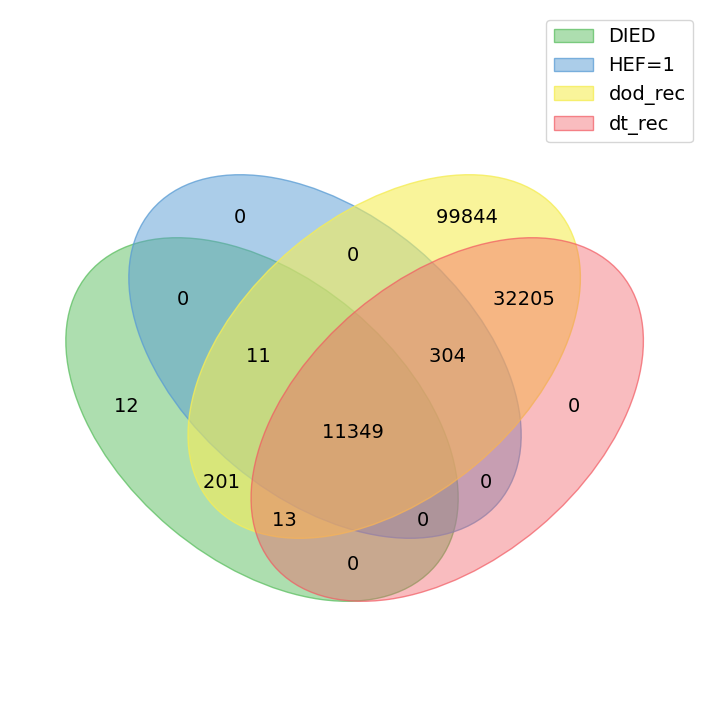

In [179]:
# 사망여부의 오류 확인 코드
def deathinfo_diagram(static_info):
    import venn 
    adms = static_info[['hadm_id', 'admittime', 'dischtime', 'dod', 'deathtime', 'discharge_location', 'hospital_expire_flag']].drop_duplicates()
    dloc = set(adms.index[adms["discharge_location"]=='DIED'])
    hef = set(adms.index[adms["hospital_expire_flag"]==1])
    dod = set(adms.index[~pd.isna(adms["dod"])])
    dt = set(adms.index[~pd.isna(adms["deathtime"])])

    labels = venn.get_labels([dloc, hef, dod, dt], fill=['number'])
    venn.venn4(labels, names=['DIED', 'HEF=1', 'dod_rec', 'dt_rec'])
    plt.show()

deathinfo_diagram(static_info)
plt.close()

In [ ]:
''' 사망여부의 오류 검사 결과: 9가지 경우가 존재함
(deathtime = dht)
1. dod 기록, dht 기록 안됨, HEF = 0, DIED가 아님: 99844 adm => 3/3 out hospital death 
2. dod 기록, dht 기록, HEF = 0, DIED가 아님: 32205 adm => 2/3 out hospital death 
3. dod 기록, dht 기록 안됨, HEF = 1, DIED가 아님: 0 adm => 2/3 out hospital death 
4. dod 기록, dht 기록, HEF = 1, DIED가 아님: 274 adm => 2/3 in hospital death 
5. dod 기록, dht 기록 안됨, HEF = 1, DIED: 11 adm => 2/3 in hospital death 
6. dod 기록, dht 기록, HEF = 1, DIED: 8727 adm => 3/3 in hospital death 
7. dod 기록, dht 기록 안됨, HEF = 0, DIED: 137 adm => 2/3 out hospital death 
8. dod 기록, dht 기록, HEF = 0, DIED: 28 adm => 2/3 in hospital death
9. dod 기록 안됨, dht 기록 안됨, HEF = 0, DIED: 5 adm => 안죽었다고 봐야하지 않을까

=> 따라서 dht가 기록된 경우 항상 dod 기록은 존재함(둘의 일치 확인 필요)
=> dod가 기록되지 않은 경우 오로지 5 admission에만 died=1 이고 나머지는 hef=0, died=0
dod == dht인지 검사 필요
'''
tmp_df = static_info[['dod','deathtime']].dropna()
all(tmp_df['dod'].dt.date == tmp_df['deathtime'].dt.date)

True

In [181]:
'''시간오류 종류는 아래와 같음.(dht = deathtime으로 표기)
1. dod, dht < at 인 경우 => 오류이거나 이미 심정지 상태로 온 것을 나타낸다고 가정하더라도....
2. at < dod, dht 인데, dod나 dht 한참(3~4일) 뒤에 discharge 하는 경우 => 가능하지만, deathtime 혹은 dod까지의 기록만 사용해야 할 것으로 보임
3. dt < dod, dht 인경우: dod이면 out of hospital 가능/ dht면 시간오류 
    3.1 dod인데 max_df+1year 보다 이후: 오류

따라서 아래와 같이 코딩함.
=> dht와 dod 정보를 기반으로 죽음에 대한 정보를 나타내고, 아래와 같은 column을 이용해 표기함.

=> deathtype: survived, in, out, out_in_24hr, out_after_365d, error
=> death_adm: 이 admission에서 사망했는지 의미
=> deathtime: 가능한 경우, 시간까지 기록된 deathtime
=> is_dht_date: deathtime이 date까지만 신뢰할지 말지
=> certainty: certain, likely, even, unlikely, error ==> 오류가 없음 ~ 오류임
'''
def death_error_handling(x):
    import pandas as pd
    import datetime
    # static_info should be sorted in admittime
    adms = x[['hadm_id', 'admittime', 'dischtime', 'dod', 'deathtime', 'died', 'hospital_expire_flag']].drop_duplicates().sort_values('admittime').reset_index(drop=True)
    adms.columns = ['id', 'at', 'dt', 'dod', 'dht', 'died', 'hef']
    dod, dht = adms.loc[0, ['dod', 'dht']].values
    dod = pd.Timestamp(dod.date())
    hour = datetime.timedelta(hours=1)
    day = datetime.timedelta(days=1)
    
    return_df = pd.DataFrame(columns=['hadm_id', 'deathtype', 'death_adm', 'deathtime', 'is_dht_date', 'certainty'])
    return_df['hadm_id'] = adms['id'].copy()
    return_df['death_adm'] = 0

    try:
        if pd.isna(dod):
            return_df['deathtype'] = 'survived'
            if adms['died'].sum() >= 1 : 
                return_df['certainty'] = 'likely'
            else: 
                return_df['certainty'] = 'certain'

            return return_df
        
        elif pd.notna(dht):
            return_df['is_dht_date'] = 0
            return_df['deathtime'] = dht
            if (dht <= adms['at']).any(): 
                return_df['deathtype'] = 'error'
                return_df['certainty'] = 'error'

                return return_df
            
            else: 
                in_death = (adms['at'] < dht) & (dht <= adms['dt'])
                
                last_dt = adms['dt'].iloc[-1]
                out_death = ((last_dt+24*hour) < dht) & (dht <= (last_dt+365*day)) 
                out_in_24hr = (last_dt < dht) & (dht <= (last_dt+24*hour))
                out_after_365d = (last_dt+365*day) < dht

                if in_death.sum() >= 1: 
                    return_df['deathtype'] = 'in'
                    return_df.loc[in_death, 'death_adm'] = 1
                    
                    if in_death.sum() > 1:
                        return_df['certainty'] = 'error'
                    else:
                        died, hef = adms.loc[in_death, ['died', 'hef']].values.ravel()
                        
                        if (hef+died) == 2: 
                            return_df['certainty'] = 'certain'
                        elif (hef+died) == 1 :
                            return_df['certainty'] = 'likely'
                        else:
                            return_df['certainty'] = 'even'

                    return return_df
                    
                elif out_death:
                    return_df['deathtype'] = 'out'
                    errors = adms[['died', 'hef']].values.sum()

                    if errors >= 2: 
                        return_df['certainty'] = 'unlikely'
                    elif errors == 1 :
                        return_df['certainty'] = 'even'
                    else:
                        return_df['certainty'] = 'likely'

                    return return_df
                
                elif out_in_24hr:
                    return_df['deathtype'] = 'out_in_24hr'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                    
                elif out_after_365d:
                    return_df['deathtype'] = 'out_after_365d'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                
                else: 
                    raise LookupError
                
        else:
            return_df['is_dht_date'] = 1
            return_df['deathtime'] = dod
            adms['at'] = pd.to_datetime(adms['at'].dt.date)
            adms['dt'] = pd.to_datetime(adms['dt'].dt.date)

            if (dod < adms['at']).any(): 
                return_df['deathtype'] = 'error'
                return_df['certainty'] = 'error'

                return return_df
            
            else: 
                in_death = (adms['at'] <= dod) & (dod <= adms['dt'])
                
                last_dt = adms['dt'].iloc[-1]
                out_death = ((last_dt+day) < dod) & (dod <= (last_dt+365*day)) 
                out_in_24hr = (last_dt+day == dod)
                out_after_365d = (last_dt+365*day) < dod

                if in_death.sum() >= 1: 
                    return_df['deathtype'] = 'in'
                    return_df.loc[in_death, 'death_adm'] = 1
                    
                    if in_death.sum() > 1:
                        return_df['certainty'] = 'error'
                    else:
                        died, hef = adms.loc[in_death, ['died', 'hef']].values.ravel()
                        
                        if (hef+died) == 2: 
                            return_df['certainty'] = 'likely'
                        elif (hef+died) == 1 :
                            return_df['certainty'] = 'even'
                        else:
                            return_df['certainty'] = 'unlikely'

                    return return_df
                    
                elif out_death:
                    return_df['deathtype'] = 'out'
                    errors = adms[['died', 'hef']].values.sum()

                    if errors >= 2: 
                        return_df['certainty'] = 'even'
                    elif errors == 1 :
                        return_df['certainty'] = 'likely'
                    else:
                        return_df['certainty'] = 'certain'

                    return return_df
                
                elif out_in_24hr:
                    return_df['deathtype'] = 'out_in_24hr'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                    
                elif out_after_365d:
                    return_df['deathtype'] = 'out_after_365d'
                    errors = adms[['died', 'hef']].values.sum()
                    return_df['certainty'] = errors/(adms.shape[0]*2)

                    return return_df
                
                else: 
                    raise LookupError
    except:
        print(x['subject_id'].iloc[0])
        raise LookupError
tmp_df = static_info.groupby('subject_id').parallel_apply(death_error_handling)
tmp_df

/home/DAHS1/anaconda3/envs/backup_06/lib/python3.10/site-packages/pandarallel/data_types/dataframe_groupby.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return df_groupby._wrap_applied_output(*args, not_indexed_same=mutated)


hadm_id deathtype  death_adm           deathtime is_dht_date  \
subject_id                                                                      
10000032   0  22595853.0       out          0 2180-09-09 00:00:00           1   
           1  22841357.0       out          0 2180-09-09 00:00:00           1   
           2  29079034.0       out          0 2180-09-09 00:00:00           1   
           3  25742920.0       out          0 2180-09-09 00:00:00           1   
10000068   0  25022803.0  survived          0                 NaT         NaN   
...                  ...       ...        ...                 ...         ...   
19999828   0  29734428.0  survived          0                 NaT         NaN   
           1  25744818.0  survived          0                 NaT         NaN   
19999840   0  26071774.0        in          0 2164-09-17 13:42:00           0   
           1  21033226.0        in          1 2164-09-17 13:42:00           0   
19999987   0  23865745.0  survived          0                 NaT         NaN   

             certainty  
subject_id              
10000032   0   certain  
           1   certain  
           2   certain  
           3   certain  
10000068   0   certain  
...                ...  
19999828   0   certain  
           1   certain  
19999840   0   certain  
           1   certain  
19999987   0   certain  

[543628 rows x 6 columns]

In [182]:
for col in tmp_df.columns:
    print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')

/tmp/ipykernel_1873647/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


hadm_id: 99984


/tmp/ipykernel_1873647/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


deathtype: 0


/tmp/ipykernel_1873647/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


...

deathtime: 0


/tmp/ipykernel_1873647/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


is_dht_date: 0


/tmp/ipykernel_1873647/3113233692.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f'{col}: {(tmp_df.fillna(0).groupby("subject_id")[col].apply(np.unique).apply(len)>1).sum()}')


certainty: 0


In [183]:
static_info = static_info.drop(columns=['deathtime', 'dod', 'hospital_expire_flag', 'died']).set_index(['hadm_id']).join(tmp_df.reset_index(drop=True).set_index(['hadm_id']), how='left').reset_index()

## Race Handling

In [184]:
# races
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
tmp_df.loc[pd.isna(tmp_df).sum(axis=1)<32] # 이런 케이스가 대체 왜 있는거지?

race,AMERICAN INDIAN/ALASKA NATIVE,ASIAN,ASIAN - ASIAN INDIAN,ASIAN - CHINESE,ASIAN - KOREAN,ASIAN - SOUTH EAST ASIAN,BLACK/AFRICAN,BLACK/AFRICAN AMERICAN,BLACK/CAPE VERDEAN,BLACK/CARIBBEAN ISLAND,HISPANIC OR LATINO,HISPANIC/LATINO - CENTRAL AMERICAN,HISPANIC/LATINO - COLUMBIAN,HISPANIC/LATINO - CUBAN,HISPANIC/LATINO - DOMINICAN,HISPANIC/LATINO - GUATEMALAN,HISPANIC/LATINO - HONDURAN,HISPANIC/LATINO - MEXICAN,HISPANIC/LATINO - PUERTO RICAN,HISPANIC/LATINO - SALVADORAN,MULTIPLE RACE/ETHNICITY,NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,OTHER,PATIENT DECLINED TO ANSWER,PORTUGUESE,SOUTH AMERICAN,UNABLE TO OBTAIN,UNKNOWN,WHITE,WHITE - BRAZILIAN,WHITE - EASTERN EUROPEAN,WHITE - OTHER EUROPEAN,WHITE - RUSSIAN
subject_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
10002013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,16.0,NaN,NaN,NaN,NaN
10002869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN
10003502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0
10003731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN
10004457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN
19994592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19995320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN


In [185]:
# 이 환자들의 인종 정보는 명확하게 결정할 수 없다고 가정
# 더불어, AKI의 보수적 판단(쉽게 AKI로 평가)을 위해서 흑인 포함 다인종이더라도 흑인이 아니라고 하는 것이 더 타당하다고 결론지음
# 이에 하기 규칙 5.와 같이 판단함

In [186]:
race_mapping = {
    'ASIAN': 'ASIAN',
    'ASIAN - ASIAN INDIAN': 'ASIAN',
    'ASIAN - CHINESE': 'ASIAN', 
    'ASIAN - KOREAN': 'ASIAN', 
    'ASIAN - SOUTH EAST ASIAN': 'ASIAN',

    'BLACK/AFRICAN': 'BLACK', 
    'BLACK/AFRICAN AMERICAN': 'BLACK',
    'BLACK/CAPE VERDEAN': 'BLACK',
    'BLACK/CARIBBEAN ISLAND': 'BLACK', 

    'HISPANIC OR LATINO': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - COLUMBIAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - CUBAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - DOMINICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - HONDURAN': 'HISPANIC/LATINO',
    'HISPANIC/LATINO - MEXICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC/LATINO', 
    'HISPANIC/LATINO - SALVADORAN': 'HISPANIC/LATINO',
    'PORTUGUESE': 'HISPANIC/LATINO',
    'SOUTH AMERICAN': 'HISPANIC/LATINO', 

    'WHITE': 'WHITE', 
    'WHITE - BRAZILIAN': 'WHITE', 
    'WHITE - EASTERN EUROPEAN': 'WHITE', 
    'WHITE - OTHER EUROPEAN': 'WHITE',
    'WHITE - RUSSIAN': 'WHITE', 

    'OTHER': 'OTHER',
    'AMERICAN INDIAN/ALASKA NATIVE': 'OTHER', 
    'MULTIPLE RACE/ETHNICITY': 'OTHER',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'OTHER',

    'UNKNOWN': 'UNKNOWN',
    'UNABLE TO OBTAIN': 'UNKNOWN', 
    'PATIENT DECLINED TO ANSWER': 'UNKNOWN'
}

static_info['race'] = static_info['race'].map(race_mapping)

# 규칙 5 적용
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
race_error_subjects = tmp_df.loc[pd.isna(tmp_df).sum(axis=1)<=(6-2)].index.tolist()# race가 여러개 기록된 환자들의 subject id
static_info.loc[static_info['subject_id'].isin(race_error_subjects), 'race'] = 'OTHER'

In [187]:
tmp_df = static_info.groupby('subject_id')['race'].value_counts().unstack()
tmp_df = tmp_df[tmp_df>=1]
tmp_df.loc[pd.notna(tmp_df).sum(axis=1)!=1] # 해결

race,ASIAN,BLACK,HISPANIC/LATINO,OTHER,UNKNOWN,WHITE
subject_id,,,,,,


## Age

In [188]:
# age missing value
pd.isna(static_info['anchor_age']).sum()

0

In [189]:
# intime 및 admittime에서의 나이를 계산함.
static_info.anchor_year = pd.to_datetime(static_info.anchor_year.astype(str)+'-01-01') # assume that all patients were born at Jan 1st
static_info['age_at_intime'] = (static_info['intime'] - static_info['anchor_year'])/datetime.timedelta(days = 365) + static_info['anchor_age']
static_info['age_at_admittime'] = (static_info['admittime'] - static_info['anchor_year'])/datetime.timedelta(days = 365) + static_info['anchor_age']

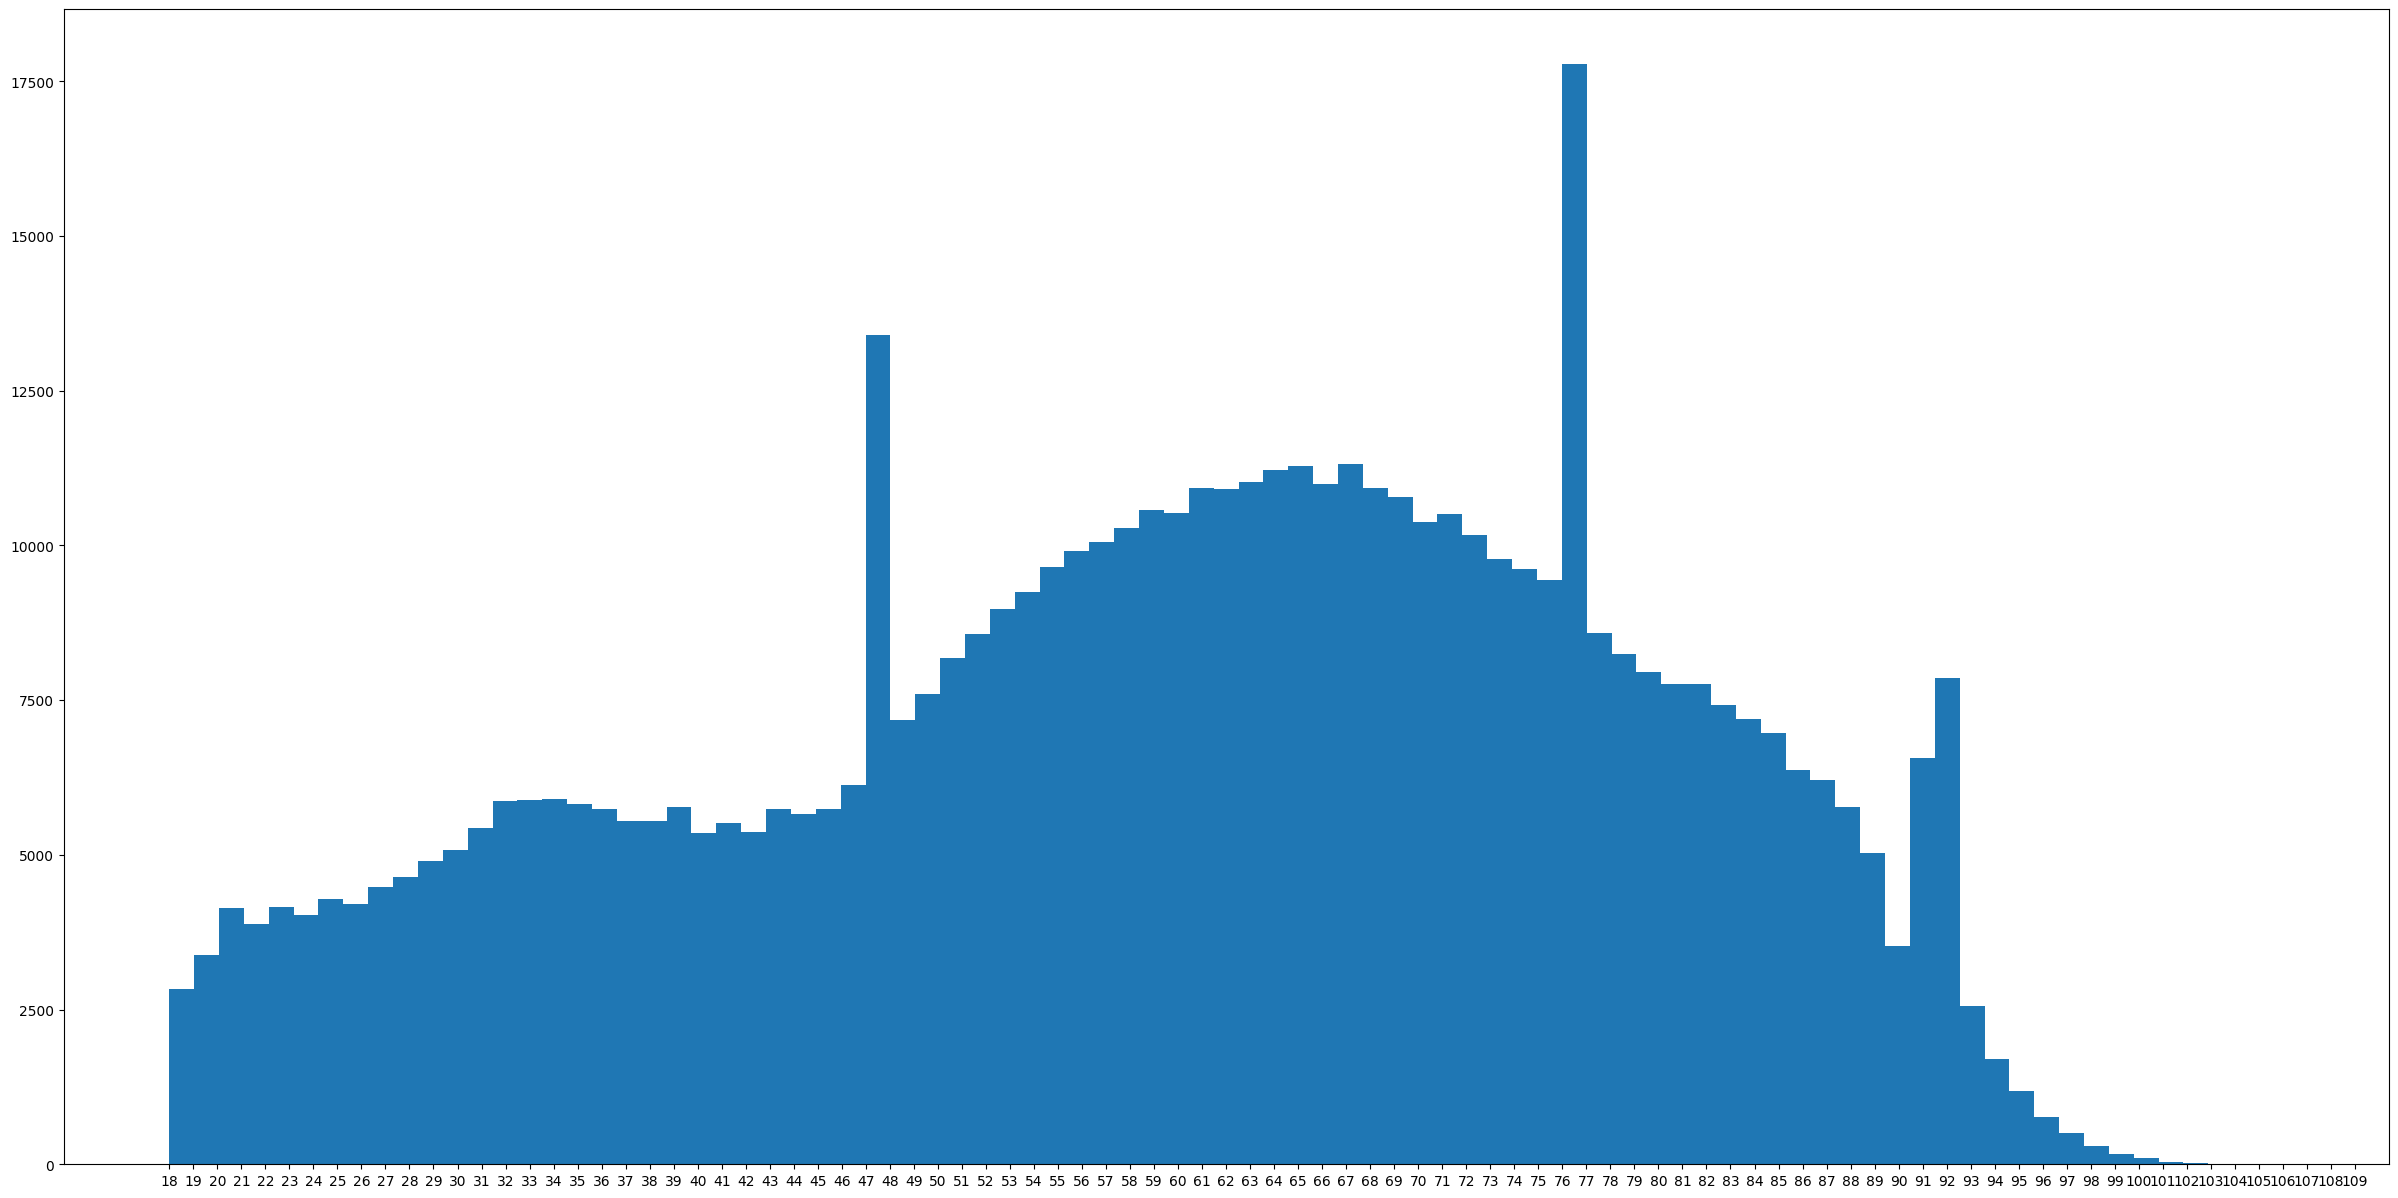

In [190]:
# age distribution
plt.figure(figsize=(30, 15))
plt.hist(round(static_info.age_at_admittime),85)
plt.xticks(np.arange(18, 110, 1))
plt.show()

In [191]:
col_names = ['stay_id', 'hadm_id', 'subject_id', 'intime', 'outtime', 'admittime', 'dischtime', 'edregtime', 'edouttime', 
             'first_careunit', 'last_careunit', 'admission_location', 'discharge_location', 
             'admission_type', 'insurance', 'language', 'marital_status', 
             'los', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'age_at_intime', 'age_at_admittime', 'race', 
             'deathtype', 'death_adm', 'deathtime', 'is_dht_date', 'certainty']

static_info = static_info.sort_values(['subject_id', 'admittime', 'intime']).reset_index()

static_info = static_info[col_names]

In [192]:
# LOS check
a = ((static_info['outtime'].dropna()-static_info['intime']).dropna()/datetime.timedelta(days=1))
all(static_info['los'].dropna()-a < 1e-7)

True

In [ ]:
static_info.to_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv', index=False)

In [ ]:
static_info

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaT,NaT,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1,certain
1,NaN,22841357.0,10000032,NaT,NaT,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1,certain
3,NaN,25742920.0,10000032,NaT,NaT,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1,certain
4,NaN,25022803.0,10000068,NaT,NaT,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,None,EU OBSERVATION,None,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaT,NaN,certain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
552824,NaN,29734428.0,19999828,NaT,NaT,2147-07-18 16:23:00,2147-08-04 18:10:00,2147-07-17 17:18:00,2147-07-18 17:34:00,NaN,NaN,PHYSICIAN REFERRAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,NaN,F,46,2147-01-01,2017 - 2019,NaN,46.544336,WHITE,survived,0,NaT,NaN,certain
552825,36075953.0,25744818.0,19999828,2149-01-08 18:12:00,2149-01-10 13:11:02,2149-01-08 16:44:00,2149-01-18 17:00:00,2149-01-08 09:11:00,2149-01-08 18:12:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,HOME HEALTH CARE,EW EMER.,Medicaid,English,SINGLE,1.790995,F,46,2147-01-01,2017 - 2019,48.023995,48.023828,WHITE,survived,0,NaT,NaN,certain
552826,NaN,26071774.0,19999840,NaT,NaT,2164-07-25 00:27:00,2164-07-28 12:15:00,2164-07-24 21:16:00,2164-07-25 01:20:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Private,English,WIDOWED,NaN,M,58,2164-01-01,2008 - 2010,NaN,58.564435,WHITE,in,0,2164-09-17 13:42:00,0,certain
552827,38978960.0,21033226.0,19999840,2164-09-12 09:26:28,2164-09-17 16:35:15,2164-09-10 13:47:00,2164-09-17 16:35:15,2164-09-10 11:09:00,2164-09-10 14:46:00,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,DIED,EW EMER.,Private,English,WIDOWED,5.297766,M,58,2164-01-01,2008 - 2010,58.699708,58.694724,WHITE,in,1,2164-09-17 13:42:00,0,certain


In [ ]:
static_info['death_adm'].value_counts()

death_adm
0    539239
1     13590
Name: count, dtype: int64

In [ ]:
static_info.columns

Index(['stay_id', 'hadm_id', 'subject_id', 'intime', 'outtime', 'admittime',
       'dischtime', 'edregtime', 'edouttime', 'first_careunit',
       'last_careunit', 'admission_location', 'discharge_location',
       'admission_type', 'insurance', 'language', 'marital_status', 'los',
       'gender', 'anchor_age', 'anchor_year', 'anchor_year_group',
       'age_at_intime', 'age_at_admittime', 'race', 'deathtype', 'death_adm',
       'deathtime', 'is_dht_date', 'certainty'],
      dtype='object')

---

# 2. DuETT Preprocessing

In [5]:
static_info = pd.read_csv('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/mimic/physionet.org/files/mimiciv/3.1/hosp/static_info.csv')

In [6]:
static_info.head()

,stay_id,hadm_id,subject_id,intime,outtime,admittime,dischtime,edregtime,edouttime,first_careunit,last_careunit,admission_location,discharge_location,admission_type,insurance,language,marital_status,los,gender,anchor_age,anchor_year,anchor_year_group,age_at_intime,age_at_admittime,race,deathtype,death_adm,deathtime,is_dht_date,certainty
0,NaN,22595853.0,10000032,NaN,NaN,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-05-06 19:17:00,2180-05-06 23:30:00,NaN,NaN,TRANSFER FROM HOSPITAL,HOME,URGENT,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.347761,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
1,NaN,22841357.0,10000032,NaN,NaN,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-06-26 15:54:00,2180-06-26 21:31:00,NaN,NaN,EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.487038,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
2,39553978.0,29079034.0,10000032,2180-07-23 14:00:00,2180-07-23 23:50:47,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,HOME,EW EMER.,Medicaid,English,WIDOWED,0.410266,F,52,2180-01-01,2014 - 2016,52.560502,52.560341,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
3,NaN,25742920.0,10000032,NaN,NaN,2180-08-05 23:44:00,2180-08-07 17:50:00,2180-08-05 20:58:00,2180-08-06 01:44:00,NaN,NaN,EMERGENCY ROOM,HOSPICE,EW EMER.,Medicaid,English,WIDOWED,NaN,F,52,2180-01-01,2014 - 2016,NaN,52.597230,WHITE,out,0,2180-09-09 00:00:00,1.0,certain
4,NaN,25022803.0,10000068,NaN,NaN,2160-03-03 23:16:00,2160-03-04 06:26:00,2160-03-03 21:55:00,2160-03-04 06:26:00,NaN,NaN,EMERGENCY ROOM,NaN,EU OBSERVATION,NaN,English,SINGLE,NaN,F,19,2160-01-01,2008 - 2010,NaN,19.172519,WHITE,survived,0,NaN,NaN,certain


In [7]:
# static_info랑 비교해서 merge를 하던 정보를 어떻게 결합할지 정해야 함. 로직 검증 필수

"""
key_id_icu 생성 방법은 매우 간단했음.
# patient static information dataframe 만들기
## admission 결합하기
df_adm = df_admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_adm = key_id.merge(df_adm, on = ['subject_id', 'hadm_id'])

## icu 결합하기
key_id_icu = key_id_adm.merge(df_icustays, on=['subject_id', 'hadm_id','stay_id'])
"""

key_id_icu.head()

,subject_id,hadm_id,stay_id,admittime,dischtime,edregtime,edouttime,intime,outtime,los,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,first_careunit,last_careunit
0,10000032,29079034,39553978,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-07-23 05:54:00,2180-07-23 14:00:00,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
1,10000690,25860671,37081114,2150-11-02 18:02:00,2150-11-12 13:45:00,2150-11-02 11:41:00,2150-11-02 19:37:00,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,English,WIDOWED,WHITE,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
2,10000980,26913865,39765666,2189-06-27 07:38:00,2189-07-03 03:00:00,2189-06-27 06:25:00,2189-06-27 08:42:00,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,English,MARRIED,BLACK/AFRICAN AMERICAN,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU)
3,10001217,24597018,37067082,2157-11-18 22:56:00,2157-11-25 18:00:00,2157-11-18 17:38:00,2157-11-19 01:24:00,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)
4,10001217,27703517,34592300,2157-12-18 16:58:00,2157-12-24 14:55:00,None,None,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,Other,MARRIED,WHITE,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU)


In [8]:
key_id_only_ids = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]
temp = key_id_only_ids.merge(static_info, how='left', on=['subject_id', 'hadm_id', 'stay_id'])

print(len(temp))
print(temp['death_adm'].value_counts())

temp = temp[temp['intime'].notnull()].reset_index(drop=True)
temp = temp[['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'admission_location', 'admission_type', 'age_at_intime', 'gender', 'race', 'death_adm']]
print("age 처리 형태")
print(temp['age_at_intime'])

84206
death_adm
0.0    74284
1.0     9791
Name: count, dtype: int64
age 처리 형태
0        52.560502
1        86.837856
2        76.488664
3        55.887135
4        55.966177
           ...    
84070    43.886575
84071    82.774806
84072    48.023995
84073    58.699708
84074    57.838240
Name: age_at_intime, Length: 84075, dtype: float64


In [ ]:
patients = temp.copy()

# 결측 없는 온전한 데이터 + 나이 필터링 (18세 이상 90세 미만)
static_df = patients[(patients['age_at_intime'] >= 18.0) & (patients['age_at_intime'] <= 90.0)].reset_index(drop=True)
test = static_df.copy()


# Groupping demo information

## Admission type mapping
admission_type_map = {
    'EW EMER.': 'EMERGENCY', 'DIRECT EMER.': 'EMERGENCY', 'URGENT': 'EMERGENCY',
    'OBSERVATION ADMIT': 'OBSERVATION', 'EU OBSERVATION': 'OBSERVATION', 
    'DIRECT OBSERVATION': 'OBSERVATION', 'AMBULATORY OBSERVATION': 'OBSERVATION',
    'ELECTIVE': 'ELECTIVE', 'SURGICAL SAME DAY ADMISSION': 'ELECTIVE'
}
test['admission_type_grouped'] = test['admission_type'].map(admission_type_map)

## Admission location mapping
admission_location_map = {
    'EMERGENCY ROOM': 'EMERGENCY', 'WALK-IN/SELF REFERRAL': 'EMERGENCY',
    'PHYSICIAN REFERRAL': 'REFERRAL', 'CLINIC REFERRAL': 'REFERRAL',
    'TRANSFER FROM HOSPITAL': 'TRANSFER', 'TRANSFER FROM SKILLED NURSING FACILITY': 'TRANSFER', 'AMBULATORY SURGERY TRANSFER': 'TRANSFER',
    'PROCEDURE SITE': 'PROCEDURE_PACU', 'PACU': 'PROCEDURE_PACU',
    'INFORMATION NOT AVAILABLE': 'OTHER_UNKNOWN', 'INTERNAL TRANSFER TO OR FROM PSYCH': 'OTHER_UNKNOWN'
}
test['admission_location_grouped'] = test['admission_location'].map(admission_location_map)

## First careunit mapping
def group_careunit(unit):
    if unit in ['Medical Intensive Care Unit (MICU)', 'Medicine', 'Med/Surg']:
        return 'MICU'
    elif unit in ['Surgical Intensive Care Unit (SICU)', 'Surgery/Vascular/Intermediate', 'Surgery/Trauma']:
        return 'SICU'
    elif unit in ['Medical/Surgical Intensive Care Unit (MICU/SICU)', 'Intensive Care Unit (ICU)']:
        return 'MICU_SICU'
    elif unit in ['Cardiac Vascular Intensive Care Unit (CVICU)', 'Coronary Care Unit (CCU)', 'Medicine/Cardiology Intermediate']:
        return 'CARDIAC'
    elif unit in ['Trauma SICU (TSICU)']:
        return 'TSICU'
    elif unit in ['Neuro Intermediate', 'Neuro Stepdown', 'Neuro Surgical Intensive Care Unit (Neuro SICU)', 'Neurology']:
        return 'NEURO'
    else:
        return 'OTHER'

test['first_careunit_grouped'] = test['first_careunit'].apply(group_careunit)

### One-hot encoding
test_encoded = pd.get_dummies(test, columns=['admission_type_grouped', 'admission_location_grouped', 'first_careunit_grouped'], dtype=int)

test_encoded = pd.get_dummies(test_encoded, columns=['race'], dtype=int)

final_static_df = pd.get_dummies(test_encoded, columns=['gender'], dtype=int)

In [10]:
# After one-hot encoding -> ready for injecting to model
final_static_df

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,admission_location,admission_type,age_at_intime,death_adm,admission_type_grouped_ELECTIVE,admission_type_grouped_EMERGENCY,admission_type_grouped_OBSERVATION,admission_location_grouped_EMERGENCY,admission_location_grouped_OTHER_UNKNOWN,admission_location_grouped_PROCEDURE_PACU,admission_location_grouped_REFERRAL,admission_location_grouped_TRANSFER,first_careunit_grouped_CARDIAC,first_careunit_grouped_MICU,first_careunit_grouped_MICU_SICU,first_careunit_grouped_NEURO,first_careunit_grouped_OTHER,first_careunit_grouped_SICU,first_careunit_grouped_TSICU,race_ASIAN,race_BLACK,race_HISPANIC/LATINO,race_OTHER,race_UNKNOWN,race_WHITE,gender_F,gender_M
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,52.560502,0.0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,86.837856,0.0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),EMERGENCY ROOM,EW EMER.,76.488664,0.0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,EW EMER.,55.887135,0.0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),PHYSICIAN REFERRAL,DIRECT EMER.,55.966177,0.0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84070,19999442,26785317,32336619,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),PHYSICIAN REFERRAL,ELECTIVE,43.886575,0.0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1
84071,19999625,25304202,31070865,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),EMERGENCY ROOM,EW EMER.,82.774806,0.0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
84072,19999828,25744818,36075953,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),TRANSFER FROM HOSPITAL,EW EMER.,48.023995,0.0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0
84073,19999840,21033226,38978960,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),EMERGENCY ROOM,EW EMER.,58.699708,1.0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1


In [11]:
lab_imputed_chart = lab_imputed_chart.rename(columns={"measure_count": "count"})
lab_imputed_chart['feature_name'].unique()

array(['Brain Natiuretic Peptide', 'albumin', 'alt', 'anion_gap',
       'art_ph', 'ast', 'base_excess', 'bilirubin', 'bun', 'ca_ion',
       'chloride', 'ck_mb', 'creatinine', 'd-dimer', 'fio2', 'gcs',
       'glucose', 'heart_rate', 'hematocrit', 'hemoglobin', 'lactate',
       'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc'],
      dtype=object)

In [12]:
lab_imputed_chart

,stay_id,slot_idx,slot_start,feature_name,value,count
0,30000153,0,2174-09-29 12:09:00,Brain Natiuretic Peptide,0.0,0
1,30000153,1,2174-09-29 13:09:00,Brain Natiuretic Peptide,0.0,0
2,30000153,2,2174-09-29 14:09:00,Brain Natiuretic Peptide,0.0,0
3,30000153,3,2174-09-29 15:09:00,Brain Natiuretic Peptide,0.0,0
4,30000153,4,2174-09-29 16:09:00,Brain Natiuretic Peptide,0.0,0
...,...,...,...,...,...,...
239957515,39999858,89,2167-04-30 05:36:00,wbc,0.0,0
239957516,39999858,90,2167-04-30 06:36:00,wbc,0.0,0
239957517,39999858,91,2167-04-30 07:36:00,wbc,0.0,0
239957518,39999858,92,2167-04-30 08:36:00,wbc,0.0,0


## Pivotting

In [13]:
df_pivot_value = lab_imputed_chart.pivot_table(
    index=['stay_id', 'slot_idx'],
    columns='feature_name',
    values=['value', 'count']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [14]:
df_pivot_value

,stay_id_,slot_idx_,count_Brain Natiuretic Peptide,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_d-dimer,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hematocrit,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,Brain Natiuretic Peptide,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,d-dimer,fio2,gcs,glucose,heart_rate,hematocrit,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc
0,30000153,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,9.0,0.0,104.0,35.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.000000,0.00,0.0
1,30000153,1,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.30,0.0,-3.0,0.0,0.0,1.1,112.0,0.0,0.0,0.0,0.0,0.0,176.0,0.0,33.0,10.9,2.1,0.0,45.0,263.0,0.0,4.2,0.0,0.0,16.0,142.0,37.277778,0.00,0.0
2,30000153,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0.0
3,30000153,3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,2.0,2.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,12.0,7.31,0.0,-4.0,0.0,22.0,0.0,115.0,20.0,0.9,0.0,50.0,0.0,175.0,83.0,31.7,10.8,0.0,100.0,42.0,215.0,173.0,4.4,1.1,25.3,16.0,142.0,37.300000,0.01,17.0
4,30000153,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,103.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.000000,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271435,39999858,89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.000000,0.00,0.0
7271436,39999858,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,156.0,96.0,0.0,0.0,0.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,0.0,0.000000,0.00,0.0
7271437,39999858,91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,82.0,0.0,0.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,0.0,36.888889,0.00,0.0
7271438,39999858,92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0.0


In [15]:
sequential_df_output = sequential_df_output[['stay_id', 'slot_idx', 'urine_output', 'urine_count']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_output

,stay_id,slot_idx,urine,urine_count
0,30000153,0,36.884735,1
1,30000153,1,28.228259,1
2,30000153,2,50.000000,1
3,30000153,3,49.322034,1
4,30000153,4,44.035920,1
...,...,...,...,...
7271435,39999858,89,0.000000,0
7271436,39999858,90,0.000000,0
7271437,39999858,91,0.000000,0
7271438,39999858,92,0.000000,0


In [16]:
sequential_df_fluid = sequential_df_fluid.drop(columns=['fluid_category'])
sequential_df_fluid = sequential_df_fluid[['stay_id', 'slot_idx', 'input_amount', 'input_count']]
sequential_df_fluid = sequential_df_fluid.rename(columns={'input_amount':'fluid_cumul', 'input_count':'fluid_count'})
sequential_df_fluid = sequential_df_fluid.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_fluid

,stay_id,slot_idx,fluid_cumul,fluid_count
0,30000153,0,44.910364,4
1,30000153,1,8.117000,1
2,30000153,2,3.921569,1
3,30000153,3,28.057321,1
4,30000153,4,83.407346,1
...,...,...,...,...
7271435,39999858,89,0.000000,0
7271436,39999858,90,0.000000,0
7271437,39999858,91,0.000000,0
7271438,39999858,92,0.000000,0


In [17]:
sequential_df_bp = sequential_df_bp[['stay_id', 'slot_idx', 'sbp', 'dbp', 'map', 'bp_count']]
sequential_df_bp = sequential_df_bp.sort_values(['stay_id', 'slot_idx']).reset_index(drop=True)
sequential_df_bp

,stay_id,slot_idx,sbp,dbp,map,bp_count
0,30000153,0,113.0,77.0,84.0,1
1,30000153,1,131.0,61.0,80.0,2
2,30000153,2,NaN,NaN,NaN,0
3,30000153,3,109.0,55.0,71.0,2
4,30000153,4,111.0,56.0,71.0,1
...,...,...,...,...,...,...
7271435,39999858,89,NaN,NaN,NaN,0
7271436,39999858,90,NaN,NaN,NaN,0
7271437,39999858,91,NaN,NaN,NaN,0
7271438,39999858,92,NaN,NaN,NaN,0


In [18]:
# Merging
df_pivot_chart = df_pivot_value.rename(columns={'stay_id_': 'stay_id', 'slot_idx_': 'slot_idx'})

def merge_all_icu_events(df_chart, df_fluid, df_pivot_bp, df_output):
    dataframes = [df_chart, df_fluid, df_pivot_bp, df_output]

    icu_events = reduce(lambda left, right: pd.merge(left, right, on=['stay_id', 'slot_idx'], how='left'), dataframes)
    icu_events.columns = icu_events.columns.map(str)
    return icu_events

icu_events_df = merge_all_icu_events(df_pivot_chart, sequential_df_fluid, sequential_df_bp, sequential_df_output)

In [19]:
icu_events_df

,stay_id,slot_idx,count_Brain Natiuretic Peptide,count_albumin,count_alt,count_anion_gap,count_art_ph,count_ast,count_base_excess,count_bilirubin,count_bun,count_ca_ion,count_chloride,count_ck_mb,count_creatinine,count_d-dimer,count_fio2,count_gcs,count_glucose,count_heart_rate,count_hematocrit,count_hemoglobin,count_lactate,count_o2sat,count_paco2,count_pao2,count_platelets,count_potassium,count_pt_inr,count_ptt,count_resp_rate,count_sodium,count_temperature,count_troponin-T,count_wbc,Brain Natiuretic Peptide,albumin,alt,anion_gap,art_ph,ast,base_excess,bilirubin,bun,ca_ion,chloride,ck_mb,creatinine,d-dimer,fio2,gcs,glucose,heart_rate,hematocrit,hemoglobin,lactate,o2sat,paco2,pao2,platelets,potassium,pt_inr,ptt,resp_rate,sodium,temperature,troponin-T,wbc,fluid_cumul,fluid_count,sbp,dbp,map,bp_count,urine,urine_count
0,30000153,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,9.0,0.0,104.0,35.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0,0.0,0.000000,0.00,0.0,44.910364,4,113.0,77.0,84.0,1,36.884735,1
1,30000153,1,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.30,0.0,-3.0,0.0,0.0,1.1,112.0,0.0,0.0,0.0,0.0,0.0,176.0,0.0,33.0,10.9,2.1,0.0,45.0,263.0,0.0,4.2,0.0,0.0,16.0,142.0,37.277778,0.00,0.0,8.117000,1,131.0,61.0,80.0,2,28.228259,1
2,30000153,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,83.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0.0,3.921569,1,NaN,NaN,NaN,0,50.000000,1
3,30000153,3,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,2.0,2.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,12.0,7.31,0.0,-4.0,0.0,22.0,0.0,115.0,20.0,0.9,0.0,50.0,0.0,175.0,83.0,31.7,10.8,0.0,100.0,42.0,215.0,173.0,4.4,1.1,25.3,16.0,142.0,37.300000,0.01,17.0,28.057321,1,109.0,55.0,71.0,2,49.322034,1
4,30000153,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,103.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.000000,0.00,0.0,83.407346,1,111.0,56.0,71.0,1,44.035920,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271435,39999858,89,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,68.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0,0.0,0.0,0.0,27.0,0.0,0.000000,0.00,0.0,0.000000,0,NaN,NaN,NaN,0,0.000000,0
7271436,39999858,90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,156.0,96.0,0.0,0.0,0.0,88.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,0.0,0.000000,0.00,0.0,0.000000,0,NaN,NaN,NaN,0,0.000000,0
7271437,39999858,91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,82.0,0.0,0.0,0.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,0.0,36.888889,0.00,0.0,0.000000,0,NaN,NaN,NaN,0,0.000000,0
7271438,39999858,92,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,

In [20]:
icu_events_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/duett/before_norm_df_0710.ftr")

---

In [21]:
STD_VARS = [
    'albumin','alt','anion_gap','art_ph','ast','base_excess',
    'bilirubin', 'Brain Natiuretic Peptide', 'bun','ca_ion','chloride','ck_mb','creatinine',
    'd-dimer','fio2', 'gcs', 'glucose','heart_rate','hematocrit','hemoglobin',
    'lactate','o2sat','paco2','pao2','platelets','potassium',
    'pt_inr','ptt','resp_rate','sodium','temperature','troponin-T','wbc'
]

EXTRA = {
    'fluid_cumul': 'fluid_count',
    'sbp':         'bp_count',
    'dbp':         'bp_count',
    'map':         'bp_count',
    'urine':       'urine_count',
}

ALL_VARS   = STD_VARS + list(EXTRA.keys())
ALL_COUNTS = [f'count_{v}' for v in STD_VARS] + list(EXTRA.values())

In [22]:
# 컬럼 순서를 [id, slot_idx, 값 36개, count] 로 정렬
_uniq_counts = list(dict.fromkeys(ALL_COUNTS))
icu_events_df = icu_events_df[['stay_id', 'slot_idx'] + ALL_VARS + _uniq_counts]

# 매핑 누락 검사
missing = [c for c in ALL_VARS + ALL_COUNTS if c not in icu_events_df.columns]
assert not missing, f'icu_events_df에 없는 컬럼: {missing}'

print('컬럼 OK. icu_events_df shape:', icu_events_df.shape)

컬럼 OK. icu_events_df shape: (7271440, 76)


In [23]:
value_check_df = icu_events_df.copy()

exclude_cols = ['stay_id', 'slot_idx']
count_cols = [c for c in value_check_df.columns if c.startswith('count_')]
extra_count_cols = ['fluid_count', 'bp_count', 'urine_count']

cols = [
    c for c in value_check_df.columns
    if c not in exclude_cols + count_cols + extra_count_cols
]

value_check_df = (
    (value_check_df.loc[:, cols] > 0)
    .sum(axis=0)
    .reset_index()
)

value_check_df.columns = ['variable', 'exist_value']
value_check_df = value_check_df.sort_values(by='exist_value', ascending=False).reset_index(drop=True)
value_check_df

,variable,exist_value
0,heart_rate,6835873
1,resp_rate,6760579
2,o2sat,6700180
3,map,6512051
4,dbp,6512051
5,sbp,6512051
6,urine,6508844
7,fluid_cumul,5861562
8,temperature,2088513
9,gcs,1890435


In [24]:
icu_events_df = icu_events_df.drop(columns=[
    # 극도 희소 변수 제외
    'Brain Natiuretic Peptide', 'd-dimer', 
    'count_Brain Natiuretic Peptide', 'count_d-dimer',

    # MAP 제외 중복 혈압 변수 제외
    'sbp', 'dbp',
    # 빈도는 하나의 변수로 처리되어 있었음

    # hemoglobin과 너무 연관성이 높아서 삭제
    'hematocrit', 'count_hematocrit'
])

In [25]:
df_backup = icu_events_df.copy()

In [26]:
# spo2/fio2 ratio calculation
icu_events_df['fio2_for_ratio'] = icu_events_df['fio2']

icu_events_df.loc[icu_events_df['fio2_for_ratio'] > 1, 'fio2_for_ratio'] = (
    icu_events_df.loc[icu_events_df['fio2_for_ratio'] > 1, 'fio2_for_ratio'] / 100
)

valid = (
    (icu_events_df['o2sat'] > 0) &
    (icu_events_df['o2sat'] <= 100) &
    (icu_events_df['fio2_for_ratio'] >= 0.21) &
    (icu_events_df['fio2_for_ratio'] <= 1.00)
)

icu_events_df['spo2_fio2'] = 0.0
icu_events_df.loc[valid, 'spo2_fio2'] = (
    icu_events_df.loc[valid, 'o2sat'] / icu_events_df.loc[valid, 'fio2_for_ratio']
)

# spo2_fio2는 파생 변수이지만 count 변수가 필요하니 1로 넣자
icu_events_df['count_spo2_fio2'] = valid.astype(int)

icu_events_df = icu_events_df.drop(columns=['fio2_for_ratio', ])

spo2/fio2 빈도 수:  983810
spo2/fio2 Max:  476.19
spo2/fio2 Min:  1.0
spo2/fio2 Median:  235.0


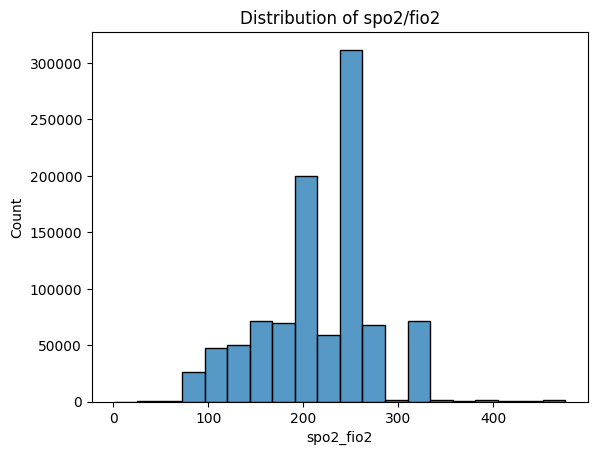

In [27]:
# spo2/fio2 check
import seaborn as sns

# 결측값 제외
sf_df = icu_events_df[icu_events_df['spo2_fio2']!=0]

print("spo2/fio2 빈도 수: ", len(sf_df))
print("spo2/fio2 Max: ", round(sf_df['spo2_fio2'].max(),2))
print("spo2/fio2 Min: ", sf_df['spo2_fio2'].min())
print("spo2/fio2 Median: ", sf_df['spo2_fio2'].median())

sns.histplot(sf_df['spo2_fio2'], bins=20)
plt.title('Distribution of spo2/fio2')
plt.show()

In [28]:
# 컬럼명 통일
icu_events_df = icu_events_df.rename(columns={
    'fluid_count': 'count_fluid_cumul',
    'bp_count': 'count_map',
    'urine_count': 'count_urine'
})

key_ids = final_static_df[['subject_id', 'hadm_id', 'stay_id']]
icu_events_df = icu_events_df.merge(key_ids, how='left', on='stay_id')

In [29]:
print(icu_events_df['subject_id'].nunique())
print(icu_events_df['hadm_id'].nunique())
print(icu_events_df['stay_id'].nunique())

58541
76274
84206


In [30]:
STD_VARS = [v for v in STD_VARS
            if v not in ['Brain Natiuretic Peptide', 'd-dimer', 'hematocrit']]
if 'spo2_fio2' not in STD_VARS:
    STD_VARS = STD_VARS + ['spo2_fio2']

EXTRA = {
    'fluid_cumul': 'count_fluid_cumul',
    'map':         'count_map',
    'urine':       'count_urine',
}

ALL_VARS   = STD_VARS + list(EXTRA.keys())
ALL_COUNTS = [f'count_{v}' for v in STD_VARS] + list(EXTRA.values())

missing = [c for c in ALL_VARS + ALL_COUNTS if c not in icu_events_df.columns]
assert not missing, f'icu_events_df에 없는 컬럼: {missing}'
print(f'[meta-sync] n_ts_vars={len(ALL_VARS)}  '
      f'(std={len(STD_VARS)}, extra={len(EXTRA)})')


LABEL_COL  = 'death_adm'
NUM_STATIC = ['age_at_intime']

# 모델 인풋에서 빼야 할 컬럼들 (식별자/시간/원본 카테고리/라벨)
DROP_COLS = [
    'subject_id', 'hadm_id', 'stay_id',
    'intime', 'outtime', 'admittime', 'dischtime',
    'first_careunit', 'last_careunit',
    'admission_location', 'admission_type', 'race', LABEL_COL
]

ONEHOT_STATIC = [c for c in final_static_df.columns if c not in DROP_COLS + NUM_STATIC]

D_STATIC = len(NUM_STATIC) + len(ONEHOT_STATIC)
print(f'd_static_num = {D_STATIC}  (numeric {len(NUM_STATIC)} + one-hot {len(ONEHOT_STATIC)})')
print('one-hot 컬럼들:', ONEHOT_STATIC)

ART_DIR = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/'
os.makedirs(ART_DIR, exist_ok=True)

icu_events_df.reset_index(drop=True).to_feather(f'{ART_DIR}/icu_events_raw.ftr')
final_static_df.reset_index(drop=True).to_feather(f'{ART_DIR}/static_full.ftr')

with open(f'{ART_DIR}/meta.pkl', 'wb') as f:
    pickle.dump({
        'STD_VARS': STD_VARS,
        'EXTRA': EXTRA,
        'ALL_VARS': ALL_VARS,
        'ALL_COUNTS': ALL_COUNTS,
        'NUM_STATIC': NUM_STATIC,
        'ONEHOT_STATIC': ONEHOT_STATIC,
        'D_STATIC': D_STATIC,
        'LABEL_COL': LABEL_COL,
    }, f)

print('saved:', ART_DIR)
print(f'  icu_events_raw.ftr : {icu_events_df.shape}')
print(f'  static_full.ftr    : {final_static_df.shape}')
print(f'  meta.pkl           : D_STATIC={D_STATIC}, n_vars={len(ALL_VARS)}')

[meta-sync] n_ts_vars=34  (std=31, extra=3)
d_static_num = 24  (numeric 1 + one-hot 23)
one-hot 컬럼들: ['admission_type_grouped_ELECTIVE', 'admission_type_grouped_EMERGENCY', 'admission_type_grouped_OBSERVATION', 'admission_location_grouped_EMERGENCY', 'admission_location_grouped_OTHER_UNKNOWN', 'admission_location_grouped_PROCEDURE_PACU', 'admission_location_grouped_REFERRAL', 'admission_location_grouped_TRANSFER', 'first_careunit_grouped_CARDIAC', 'first_careunit_grouped_MICU', 'first_careunit_grouped_MICU_SICU', 'first_careunit_grouped_NEURO', 'first_careunit_grouped_OTHER', 'first_careunit_grouped_SICU', 'first_careunit_grouped_TSICU', 'race_ASIAN', 'race_BLACK', 'race_HISPANIC/LATINO', 'race_OTHER', 'race_UNKNOWN', 'race_WHITE', 'gender_F', 'gender_M']
saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/
  icu_events_raw.ftr : (7271440, 72)
  static_full.ftr    : (84075, 32)
  meta.pkl           : D_STATIC=24, n_vars=34


In [31]:
import pandas as pd

data = pd.read_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/full_data/mimic_3_1/icu_events_raw.ftr")

In [32]:
data.columns

Index(['stay_id', 'slot_idx', 'albumin', 'alt', 'anion_gap', 'art_ph', 'ast',
       'base_excess', 'bilirubin', 'bun', 'ca_ion', 'chloride', 'ck_mb',
       'creatinine', 'fio2', 'gcs', 'glucose', 'heart_rate', 'hemoglobin',
       'lactate', 'o2sat', 'paco2', 'pao2', 'platelets', 'potassium', 'pt_inr',
       'ptt', 'resp_rate', 'sodium', 'temperature', 'troponin-T', 'wbc',
       'fluid_cumul', 'map', 'urine', 'count_albumin', 'count_alt',
       'count_anion_gap', 'count_art_ph', 'count_ast', 'count_base_excess',
       'count_bilirubin', 'count_bun', 'count_ca_ion', 'count_chloride',
       'count_ck_mb', 'count_creatinine', 'count_fio2', 'count_gcs',
       'count_glucose', 'count_heart_rate', 'count_hemoglobin',
       'count_lactate', 'count_o2sat', 'count_paco2', 'count_pao2',
       'count_platelets', 'count_potassium', 'count_pt_inr', 'count_ptt',
       'count_resp_rate', 'count_sodium', 'count_temperature',
       'count_troponin-T', 'count_wbc', 'count_fluid_cumul', 'coun